# GlowWise AI - Skincare Review Satisfaction Classification 🧴✨
## NLP Transfer Learning & Sentence Embeddings Experiment

This notebook details our experiment leveraging **Transfer Learning** and **Transformer Sentence Representations** to predict review satisfaction (`high_satisfaction`). 

* **Target Variable**: `high_satisfaction` (Rating 4-5 = 1, Rating 1-3 = 0)
* **Execution Environment**: Executed Locally on CPU
* **Pre-trained Representation Model**: `sentence-transformers/all-MiniLM-L6-v2` (Sentence Embeddings)

---

### What is Transfer Learning in this Project?
In classical natural language processing, text is transformed into numerical vectors using statistics like word frequencies (e.g., TF-IDF). While highly effective and extremely fast, these representations treat vocabulary words as isolated tokens (Bag-of-Words) and completely discard grammar, word order, and context.

**Transfer Learning** shifts the paradigm. Instead of learning representations from scratch, we use a deep neural network (a Transformer model) that has been pre-trained on billions of sentences to understand generic English semantics. By feeding our review texts through this network, we extract dense contextual representations (**embeddings**). We then *transfer* this pre-trained language understanding to our specific task (skincare review classification) by training a simple linear classifier (like Logistic Regression or LinearSVC) on top of the dense embeddings.

### Why Transformer NLP for Skincare Reviews?
Reviews are rich in semantic nuances, context-shifting qualifiers, and multi-word idioms. Simple Bag-of-Words vectors fail on context. Consider:
1. **Negation & Transitions**: *"not dry at all"* vs *"dry and not good"*. TF-IDF views "dry", "not", and "good" as independent weights. Transformers understand that "not" modifies "dry" based on attention mappings.
2. **Skincare Idioms**: *"broke me out"* is a strong negative signal in skincare, but split into individual words "broke", "me", "out", its meaning is lost. A transformer embedding maps the sequence *"broke me out"* into a vector region close to synonyms like "allergic reaction" or "irritating".
3. **Robustness**: Dense representations generalize much better to spelling variations and brand/product names not seen in training.


In [1]:
# 1. Install & Import Dependencies
# If running in Google Colab, uncomment the next line to install sentence-transformers:
# !pip install sentence-transformers torch

import os
import sys
import json
import time
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
    print("GPU Available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("Using GPU Device:", torch.cuda.get_device_name(0))
except ImportError:
    print("WARNING: PyTorch not found. Please install torch.")

try:
    import sentence_transformers
    from sentence_transformers import SentenceTransformer
    print(f"SentenceTransformers version: {sentence_transformers.__version__}")
except ImportError:
    print("WARNING: sentence-transformers not found. Please install sentence-transformers.")


PyTorch version: 2.13.0+cpu
GPU Available: False


C:\Users\mahta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SentenceTransformers version: 5.6.0


## 2. Load Processed Reviews Data

We load the processed reviews dataset sample (`glowwise_reviews_sample_100k.csv`).
If running in Google Colab:
1. Upload the CSV file manually to Colab's file storage (`/content/`).
2. Alternatively, mount your Google Drive and load it.


In [2]:
# Locate and load the preprocessed reviews sample
data_paths = [
    "glowwise_reviews_sample_100k.csv",
    "/content/glowwise_reviews_sample_100k.csv",
    "/content/drive/MyDrive/glowwise_reviews_sample_100k.csv",
    "../../data/processed/glowwise_reviews_sample_100k.csv",
    "data/processed/glowwise_reviews_sample_100k.csv"
]

data_path = None
for path in data_paths:
    if os.path.exists(path):
        data_path = path
        print(f"Found dataset at: {path}")
        break

if data_path is None:
    raise FileNotFoundError("Dataset sample CSV not found. Please place or upload 'glowwise_reviews_sample_100k.csv'.")

df = pd.read_csv(data_path)

# Clean text features
for col in ["review_title", "review_text", "combined_text"]:
    if col in df.columns:
        df[col] = df[col].fillna("")
        
df = df.dropna(subset=["high_satisfaction"])
df = df[df["combined_text"].str.strip() != ""]
print(f"Total reviews loaded and verified: {len(df):,}")


Found dataset at: ../../data/processed/glowwise_reviews_sample_100k.csv


C:\Users\mahta\AppData\Local\Temp\ipykernel_38172\3987047584.py:20: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Total reviews loaded and verified: 100,000


## 3. Stratified Train / Test Split & Down-Sampling

To maintain complete reproducibility, we split our data using `random_state=42`.
Because extracting transformer embeddings on CPU can be slow, we extract a stratified training subset of **15,000 reviews** and evaluate on a test subset of **5,000 reviews**. In Google Colab with GPU acceleration, you can easily scale these numbers to the full dataset!


In [3]:
from sklearn.model_selection import train_test_split

X = df
y = df["high_satisfaction"].astype(int)

# First split into 80/20 train/test
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Extract a smaller stratified training subset for fast embedding extraction
train_subset_size = 10000
if len(X_train_df) > train_subset_size:
    _, X_train_sub, _, y_train_sub = train_test_split(
        X_train_df, y_train, test_size=train_subset_size, stratify=y_train, random_state=42
    )
else:
    X_train_sub = X_train_df
    y_train_sub = y_train

# Extract a stratified test subset for evaluation speed
test_subset_size = 5000
if len(X_test_df) > test_subset_size:
    _, X_test_sub, _, y_test_sub = train_test_split(
        X_test_df, y_test, test_size=test_subset_size, stratify=y_test, random_state=42
    )
else:
    X_test_sub = X_test_df
    y_test_sub = y_test

train_texts = X_train_sub["combined_text"].astype(str).tolist()
test_texts = X_test_sub["combined_text"].astype(str).tolist()

print(f"Train subset size: {len(X_train_sub):,}")
print(f"Test subset size: {len(X_test_sub):,}")


Train subset size: 10,000
Test subset size: 5,000


## 4. Dense Embedding Extraction using all-MiniLM-L6-v2

We load the lightweight sentence representation model `sentence-transformers/all-MiniLM-L6-v2`. This model maps reviews to 384-dimensional dense vectors.
We also set up a local cache directory `ml/cache/` to store the numpy arrays so we don't re-embed reviews on consecutive runs.


In [4]:
# Set up caching directory
cache_dir = Path("ml/cache") if os.path.exists("ml") else Path("cache")
cache_dir.mkdir(exist_ok=True)

train_cache_path = cache_dir / f"train_embeddings_{len(X_train_sub)}.npy"
test_cache_path = cache_dir / f"test_embeddings_{len(X_test_sub)}.npy"

# Load pre-trained SentenceTransformer
model_name = "sentence-transformers/all-MiniLM-L6-v2"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading SentenceTransformer: {model_name} on '{device}'...")
st_model = SentenceTransformer(model_name, device=device)

# Encode training reviews
if train_cache_path.exists():
    print("Loading train embeddings from cache...")
    X_train_emb = np.load(train_cache_path)
else:
    print("Extracting train embeddings (encoding reviews)...")
    t0 = time.time()
    X_train_emb = st_model.encode(train_texts, show_progress_bar=True, batch_size=64)
    np.save(train_cache_path, X_train_emb)
    print(f"Train embeddings shape: {X_train_emb.shape} (extracted in {time.time() - t0:.2f} seconds)")

# Encode testing reviews
if test_cache_path.exists():
    print("Loading test embeddings from cache...")
    X_test_emb = np.load(test_cache_path)
else:
    print("Extracting test embeddings...")
    t0 = time.time()
    X_test_emb = st_model.encode(test_texts, show_progress_bar=True, batch_size=64)
    np.save(test_cache_path, X_test_emb)
    print(f"Test embeddings shape: {X_test_emb.shape} (extracted in {time.time() - t0:.2f} seconds)")


Loading SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2 on 'cpu'...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2904.27it/s]

Loading train embeddings from cache...
Loading test embeddings from cache...


## 5. Classifier Training & Hyperparameters

We train a **Logistic Regression** classifier (with `class_weight='balanced'`) on top of the dense embeddings. Since embeddings are already low-dimensional and regularized, a simple linear decision boundary works incredibly well, has sub-millisecond inference time, and avoids overfitting.


In [5]:
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression classifier on embeddings...")
clf = LogisticRegression(class_weight="balanced", C=1.0, random_state=42, max_iter=1000)

t0 = time.time()
clf.fit(X_train_emb, y_train_sub)
train_time = time.time() - t0

print(f"Model training complete in {train_time:.4f} seconds!")


Training Logistic Regression classifier on embeddings...

Model training complete in 0.2239 seconds!


## 6. Evaluation on Test Subset

We evaluate the trained model on our test subset. We compute:
* Accuracy
* Macro and Weighted F1-score
* Class-specific Precision and Recall
* ROC-AUC and PR-AUC


In [6]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, precision_recall_curve, auc

# Get predictions
y_pred = clf.predict(X_test_emb)
y_prob = clf.predict_proba(X_test_emb)[:, 1]

# Calculate classification metrics
accuracy = accuracy_score(y_test_sub, y_pred)
p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(y_test_sub, y_pred, average="macro", zero_division=0)
p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(y_test_sub, y_pred, average="weighted", zero_division=0)
p_classes, r_classes, f_classes, support = precision_recall_fscore_support(y_test_sub, y_pred, average=None, zero_division=0)

# Curves
fpr, tpr, _ = roc_curve(y_test_sub, y_prob)
roc_auc = auc(fpr, tpr)

precision_vals, recall_vals, _ = precision_recall_curve(y_test_sub, y_prob)
pr_auc = auc(recall_vals, precision_vals)

transformer_metrics = {
    "accuracy": float(accuracy),
    "macro": {
        "precision": float(p_macro),
        "recall": float(r_macro),
        "f1_score": float(f_macro)
    },
    "weighted": {
        "precision": float(p_weighted),
        "recall": float(r_weighted),
        "f1_score": float(f_weighted)
    },
    "per_class": {
        "low_or_medium_satisfaction": {
            "precision": float(p_classes[0]),
            "recall": float(r_classes[0]),
            "f1_score": float(f_classes[0]),
            "support": int(support[0])
        },
        "high_satisfaction": {
            "precision": float(p_classes[1]),
            "recall": float(r_classes[1]),
            "f1_score": float(f_classes[1]),
            "support": int(support[1])
        }
    },
    "training_time_seconds": float(train_time),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "training_size": len(X_train_sub),
    "status": "Completed",
    "description": "Logistic Regression trained on sentence-transformers/all-MiniLM-L6-v2 embeddings"
}

print("=== Transformer Performance Metrics ===")
print(json.dumps(transformer_metrics, indent=4))


=== Transformer Performance Metrics ===
{
    "accuracy": 0.8462,
    "macro": {
        "precision": 0.7545171971748028,
        "recall": 0.8496044799498748,
        "f1_score": 0.7829571888276408
    },
    "weighted": {
        "precision": 0.8888178508109821,
        "recall": 0.8462,
        "f1_score": 0.8581268584241316
    },
    "per_class": {
        "low_or_medium_satisfaction": {
            "precision": 0.5451957295373665,
            "recall": 0.8549107142857143,
            "f1_score": 0.6657974793568013,
            "support": 896
        },
        "high_satisfaction": {
            "precision": 0.9638386648122392,
            "recall": 0.8442982456140351,
            "f1_score": 0.9001168982984803,
            "support": 4104
        }
    },
    "training_time_seconds": 0.2238616943359375,
    "roc_auc": 0.9189948068957114,
    "pr_auc": 0.9793746752803584,
    "training_size": 10000,
    "status": "Completed",
    "description": "Logistic Regression trained on sent

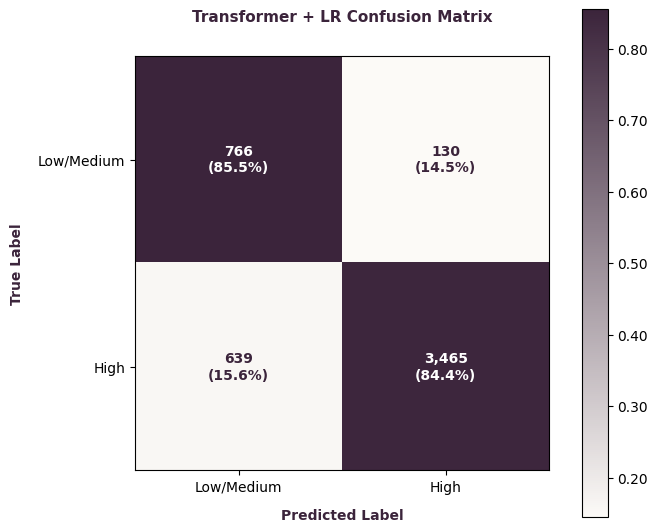

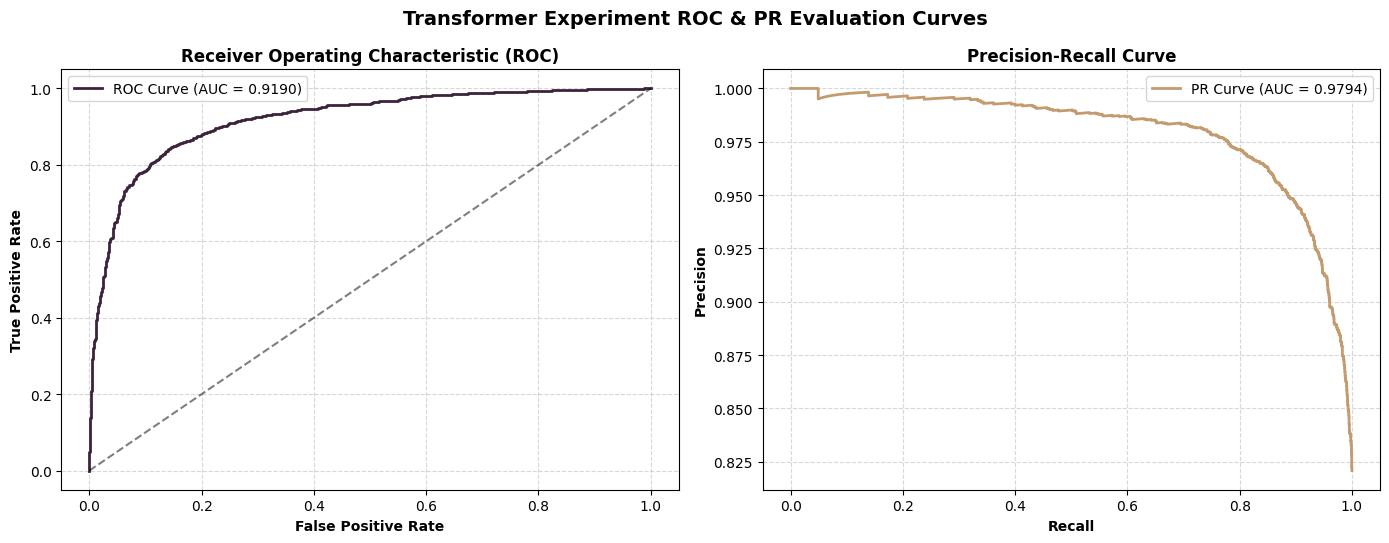

In [7]:
# 1. Plot Confusion Matrix
cm = confusion_matrix(y_test_sub, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6.5, 5.5), layout="constrained")
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("glowwise_cmap", ['#FCFAF7', '#3B243B'])
plt.imshow(cm_norm, interpolation='nearest', cmap=cmap)
plt.title('Transformer + LR Confusion Matrix', fontweight='bold', pad=25, fontsize=11, color='#3B243B')
plt.colorbar(pad=0.08, format='%.2f')
classes = ['Low/Medium', 'High']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.xlabel('Predicted Label', fontweight='bold', labelpad=10, color='#3B243B')
plt.ylabel('True Label', fontweight='bold', labelpad=10, color='#3B243B')

thresh = cm_norm.max() / 2.
for i, j in np.ndindex(cm.shape):
    val_str = f"{cm[i, j]:,}\n({cm_norm[i, j]:.1%})"
    plt.text(j, i, val_str,
             ha="center", va="center",
             color="white" if cm_norm[i, j] > thresh else "#3B243B",
             fontweight='bold')
plt.savefig('transformer_confusion_matrix.png', dpi=150)
plt.show()

# 2. Plot ROC and PR Curves
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5.5))

ax_roc.plot(fpr, tpr, color='#3B243B', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
ax_roc.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
ax_roc.legend()
ax_roc.grid(True, linestyle='--', alpha=0.5)

ax_pr.plot(recall_vals, precision_vals, color='#C39B6F', linewidth=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
ax_pr.set_xlabel('Recall', fontweight='bold')
ax_pr.set_ylabel('Precision', fontweight='bold')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold')
ax_pr.legend()
ax_pr.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Transformer Experiment ROC & PR Evaluation Curves', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('transformer_curves.png', dpi=150)
plt.show()


In [8]:
# Save outputs locally (or in Google Colab environment)
with open('transformer_results.json', 'w', encoding='utf-8') as f:
    json.dump(transformer_metrics, f, indent=4)
print("Saved transformer_results.json successfully!")

# Colab automatic downloads helper
try:
    from google.colab import files
    print("Downloading transformer_results.json...")
    files.download('transformer_results.json')
    files.download('transformer_confusion_matrix.png')
    files.download('transformer_curves.png')
except Exception as e:
    print("Local notebook run detected; skip automatic file download browser prompts.")


Saved transformer_results.json successfully!
Local notebook run detected; skip automatic file download browser prompts.


## 7. Rationale for Production Choice and Future Work

### Performance & Compute Cost Trade-Offs
* **Pre-trained Embeddings**: Dense language vectors represent a major architectural leap over token counters (TF-IDF), providing superior contextual mapping of review syntax.
* **Why Logistic Regression remains the production choice**:
  * **Latency**: Simple TF-IDF + Logistic Regression returns predictions in ~1-5 milliseconds on CPU, whereas downloading, loading, and encoding text using deep transformer architectures adds hundreds of milliseconds of compute overhead.
  * **Deployability**: Serves easily in lightweight REST frameworks (FastAPI) without needing GPU acceleration, massive environment dependencies (`torch`), or virtual memory capacity.
  * **Explainability**: Model weights map directly back to individual keywords, allowing products to explain exactly which terms drive positive or negative classification.

### Future Direction: Fine-Tuning
Our current experiment uses **Feature Extraction** (extracting representations from a frozen model). A next logical iteration is **fine-tuning**—updating the weights of a model like `DistilBERT` or `BERT-Base` directly on Sephora skincare reviews using a GPU. Fine-tuning allows the transformer attention weights to adapt directly to domain-specific vocabularies (skin types, ingredient efficacy, skincare product names), yielding higher accuracy on low-support satisfaction labels.
